# K10_00 - MNIST: Bildklassifikation mit einem Feedforward-Netz (Dozent)

## Lernziele
Nach diesem Notebook koennen Sie:
- den MNIST-Datensatz laden, normalisieren und visualisieren
- erklaeren, was der `Flatten`-Layer macht und warum das eine Schwaeche ist
- den Unterschied zwischen `sparse_categorical_crossentropy`
  und `categorical_crossentropy` erklaeren
- **Early Stopping** konfigurieren und begruenden
- Lernkurven und Konfusionsmatrix interpretieren
- Fehlklassifikationen visualisieren und analysieren


## Didaktischer Fokus

Leitfrage:
> Wie gut kann ein einfaches Feedforward-Netz Bilder klassifizieren –
> und wo liegen seine grundsaetzlichen Grenzen?

Dieses Notebook ist die **Bruecke zu CNNs**:
Wir zeigen, was ein MLP auf Bilddaten kann – und warum der `Flatten`-Schritt
strukturelle Information zerstoert, die CNNs erhalten wuerden.

**Neu gegenueber K09:**
- `Flatten`-Layer als Vorverarbeitungsschritt
- Normalisierung auf [0,1] statt `StandardScaler`
- `sparse_categorical_crossentropy` statt One-Hot-Encoding
- **Early Stopping** als Regularisierungsstrategie
- Fehlklassifikations-Visualisierung


## Imports und Reproduzierbarkeit


In [1]:
# ── Erste Zelle im Notebook ──
import time
notebook_start = time.time()
print("Notebook gestartet.")

Notebook gestartet.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random

# Seeds ganz am Anfang setzen
SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

print('Alle Bibliotheken geladen.')
print(f'TensorFlow-Version: {tf.__version__}')


Alle Bibliotheken geladen.
TensorFlow-Version: 2.20.0


## 1. MNIST-Datensatz laden

MNIST (Modified National Institute of Standards and Technology) ist
der Standarddatensatz fuer Bildklassifikation im Einstieg:

| Eigenschaft | Wert |
|---|---|
| Trainingsbilder | 60.000 |
| Testbilder | 10.000 |
| Bildgroesse | 28 x 28 Pixel |
| Farbraum | Graustufen (1 Kanal) |
| Klassen | 10 (Ziffern 0-9) |
| Pixelwerte | Integer [0, 255] |

Die Daten sind direkt in Keras eingebaut.


In [3]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f'Trainingsdaten (gesamt): {X_train_full.shape}  |  Labels: {y_train_full.shape}')
print(f'Testdaten:               {X_test.shape}  |  Labels: {y_test.shape}')
print(f'Pixelwertbereich:        [{X_train_full.min()}, {X_train_full.max()}]')
print(f'Klassen:                 {np.unique(y_train_full)}')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainingsdaten (gesamt): (60000, 28, 28)  |  Labels: (60000,)
Testdaten:               (10000, 28, 28)  |  Labels: (10000,)
Pixelwertbereich:        [0, 255]
Klassen:                 [0 1 2 3 4 5 6 7 8 9]


## 2. Beispielbilder visualisieren

Bevor wir modellieren, schauen wir uns die Daten an.
Wichtige Beobachtungen:
- unterschiedliche Handschriften innerhalb derselben Klasse
- unsaubere Formen und Verbindungen
- potenzielle Verwechslungsgefahr (z. B. 3 vs. 5, 4 vs. 9, 7 vs. 1)


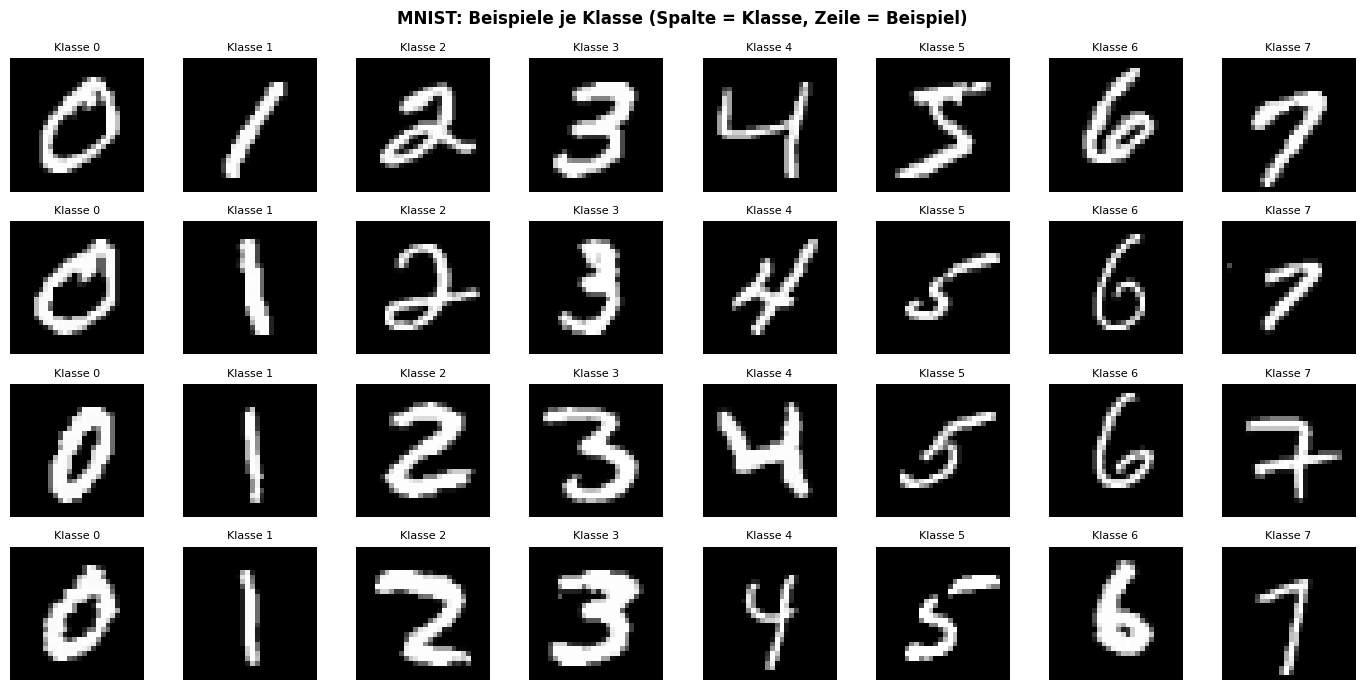

In [4]:
fig, axes = plt.subplots(4, 8, figsize=(14, 7))

# Je 4 Beispiele pro Klasse 0-7
for row, digit in enumerate(range(8)):
    idxs = np.where(y_train_full == digit)[0][:4]
    for col, idx in enumerate(idxs):
        axes[col, row].imshow(X_train_full[idx], cmap='gray')
        axes[col, row].set_title(f'Klasse {digit}', fontsize=8)
        axes[col, row].axis('off')

plt.suptitle('MNIST: Beispiele je Klasse (Spalte = Klasse, Zeile = Beispiel)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Mini-Uebung 1:** Betrachten Sie die Bilder.
- Welche Ziffern koennen leicht verwechselt werden?
- Welche sind klar erkennbar?
- Was macht handgeschriebene Ziffern schwerer zu klassifizieren
  als gedruckte?


## 3. Normalisierung

Pixelwerte liegen im Bereich [0, 255]. Neuronale Netze trainieren besser
mit kleinen, einheitlichen Werten.

**Warum hier `/255` statt `StandardScaler`?**

In K09 haben wir `StandardScaler` verwendet. Fuer Bilder ist das nicht ideal:

```
StandardScaler: berechnet pro Feature (= pro Pixel) eigenen Mittelwert
                -> 28 x 28 = 784 verschiedene Mittelwerte
                -> unnoetig komplex, loescht globale Helligkeitsinfo

/ 255:          skaliert alle Pixelwerte auf [0, 1]
                -> einfach, interpretierbar, Standard fuer Bilddaten
                -> 0 = schwarz, 1 = weiss
```

Fuer Bilddaten ist die `[0,1]`-Normalisierung der Standard.


In [5]:
X_train_full = X_train_full / 255.0
X_test       = X_test       / 255.0

print(f'Pixelwerte nach Normalisierung: [{X_train_full.min():.1f}, {X_train_full.max():.1f}]')
print(f'Mittelwert (Train):             {X_train_full.mean():.3f}')


Pixelwerte nach Normalisierung: [0.0, 1.0]
Mittelwert (Train):             0.131


## 4. Train/Validierungs-Split

Wir splitten die 60.000 Trainingsdaten in:
- **90% Training** (54.000 Bilder) – zum Lernen
- **10% Validierung** (6.000 Bilder) – fuer Early Stopping und Overfitting-Erkennung

Die 10.000 **Testdaten bleiben unangetastet** bis zur finalen Evaluation.


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1, random_state=SEED, stratify=y_train_full
)

print(f'Trainingsdaten:    {X_train.shape}')
print(f'Validierungsdaten: {X_val.shape}')
print(f'Testdaten:         {X_test.shape}')


Trainingsdaten:    (54000, 28, 28)
Validierungsdaten: (6000, 28, 28)
Testdaten:         (10000, 28, 28)


**Mini-Uebung 2:** Warum trennen wir Validierungs- und Testdaten?
Was wuerde passieren, wenn wir Early Stopping auf den Testdaten
statt auf den Validierungsdaten durchfuehren wuerden?


## 5. Das Flatten-Problem – Konzept

Bevor wir das Modell bauen, erklaeren wir den entscheidenden Schritt:

**Was macht `Flatten()`?**

```
Originalbild (28 x 28):          Nach Flatten (784 Werte):

[ [0,   0,   0,   128, ...],      [0, 0, 0, 128, ...,
  [0,   255, 200, 0,   ...],       0, 255, 200, 0, ...,
  [128, 200, 255, 128, ...],  -->   128, 200, 255, ...]
  ...                    ]

Pixel (Zeile=3, Spalte=5) und Pixel (Zeile=4, Spalte=5)
sind im Bild Nachbarn.
Im Vektor liegen sie 28 Positionen auseinander.
Das Netz sieht diese Nachbarschaft nicht mehr.
```

**Warum ist das ein Problem?**

Ein Feedforward-Netz behandelt alle 784 Pixelwerte als
unabhaengige Features – wie Tabellenspalten.
Es weiss nicht, dass benachbarte Pixel zusammengehoeren.
Eine '7' die einen Pixel nach rechts verschoben ist,
sieht im Vektor ganz anders aus – obwohl es dieselbe Ziffer ist.

**Ausblick CNN:**
Convolutional Neural Networks (K10_01) loesung genau dieses Problem:
Sie arbeiten direkt auf dem 2D-Bild und erkennen lokale Muster
unabhaengig von ihrer Position.


## 6. Feedforward-Modell definieren

```
Input (28 x 28)
    |
Flatten  ->  784 Werte
    |
Dense(256, relu)   <- Hidden Layer
    |
Dense(10, softmax) <- Ausgabeschicht (eine Klasse pro Ziffer)
```

**`sparse_categorical_crossentropy` statt `categorical_crossentropy`:**

```
K09_00:  y_cat = to_categorical(y)  ->  categorical_crossentropy
         One-Hot: [0, 0, 1, 0, ...]       Labels als Vektoren

K10_00:  y bleibt als Integer       ->  sparse_categorical_crossentropy
         Label: 7                         kein One-Hot-Schritt noetig
```

Beide sind mathematisch aequivalent. `sparse_` spart Speicher
bei vielen Klassen (hier: 10 Ziffern, spaeter: 1000 ImageNet-Klassen).


In [7]:
model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),               # 28x28 -> 784
    layers.Dense(256, activation='relu'),
    layers.Dense(10,  activation='softmax')
], name='MNIST_Feedforward')

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "MNIST_Feedforward"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

### Parameteranzahl im Vergleich

```
Flatten:     28 x 28        =       784 Eingaben (keine Parameter)
Dense(256):  784 x 256 + 256 = 200.960 Parameter
Dense(10):   256 x  10 +  10 =   2.570 Parameter
Gesamt:                        203.530 Parameter
```

Zum Vergleich:
- Iris-Modell (K09_00):             131 Parameter
- California Housing (K09_02):    2.689 Parameter
- MNIST Feedforward (dieses):   203.530 Parameter  <- 1.550x mehr als Iris!

**Warum so viele?** Jeder der 784 Pixel ist mit jedem der 256 Neuronen verbunden.
Das ist die Konsequenz aus dem Flatten-Schritt:
kein Wissen ueber Bildstruktur -> jede Verbindung muss gelernt werden.


**Mini-Uebung 3:** Das Modell hat 200.960 Parameter nur im ersten Dense-Layer.
- Warum sind es genau 784 x 256 + 256?
- Was bedeutet der '+256'-Term?
- Warum hat `Flatten()` keine Parameter?


## 7. Early Stopping

Early Stopping beendet das Training automatisch, wenn die
Validierungsleistung sich nicht mehr verbessert.

```
Ohne Early Stopping:    Mit Early Stopping:

Epoch 1:  val_loss sinkt    Epoch 1:  val_loss sinkt
Epoch 2:  val_loss sinkt    Epoch 2:  val_loss sinkt
Epoch 3:  val_loss sinkt    Epoch 3:  val_loss sinkt  <- bestes Modell
Epoch 4:  val_loss steigt   Epoch 4:  val_loss steigt  (patience=1)
Epoch 5:  val_loss steigt   Epoch 5:  val_loss steigt  (patience=2)
Epoch ...: Training laeuft  Epoch 6:  STOP             (patience=3)
           weiter -> Overfitting   Gewichte auf Epoch 3 zurueckgesetzt
```

**Parameter:**

| Parameter | Bedeutung | Wert hier |
|---|---|---|
| `monitor` | Welche Metrik beobachten? | `val_loss` |
| `patience` | Wie viele Epochen ohne Verbesserung warten? | 3 |
| `restore_best_weights` | Gewichte auf beste Epoche zuruecksetzen? | True |

**Wichtig zu `restore_best_weights=True`:**
Ohne diesen Parameter wuerden nach dem Training die Gewichte
der *letzten* Epoche verwendet – nicht der *besten*.
Da die letzten Epochen oft schlechter sind (Overfitting), ist
`restore_best_weights=True` in der Praxis fast immer sinnvoll.



In [8]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,                  # 3 Epochen ohne Verbesserung -> Stop
    restore_best_weights=True    # Gewichte auf beste Epoche zuruecksetzen
)

print('Early Stopping konfiguriert:')
print(f'  monitor:              val_loss')
print(f'  patience:             3 Epochen')
print(f'  restore_best_weights: True')


Early Stopping konfiguriert:
  monitor:              val_loss
  patience:             3 Epochen
  restore_best_weights: True


## 8. Modell trainieren

Wir setzen `epochs=50` als obere Grenze.
Early Stopping beendet das Training vorher wenn noetig.
`verbose=0` unterdrueckt die Ausgabe pro Epoche.


In [9]:
import time

start_time = time.time()

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,  # groessere Batches -> stabilere Kurven, langsameres Overfitting
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

end_time   = time.time()
laufzeit   = end_time - start_time

stopped_epoch = len(history.history['loss'])

print(f'Training beendet nach {stopped_epoch} Epochen.')
print(f'Laufzeit gesamt:    {laufzeit:.1f} Sekunden')
print(f'Laufzeit pro Epoch: {laufzeit/stopped_epoch:.2f} Sekunden')
print(f'Beste Val-Accuracy: {max(history.history["val_accuracy"]):.4f}')
print(f'Beste Val-Loss:     {min(history.history["val_loss"]):.4f}')


Training beendet nach 14 Epochen.
Laufzeit gesamt:    43.6 Sekunden
Laufzeit pro Epoch: 3.11 Sekunden
Beste Val-Accuracy: 0.9762
Beste Val-Loss:     0.0821


## 9. Lernkurven analysieren

**Worauf achten?**
- Kurven sinken parallel -> gute Generalisierung
- Grosser Abstand Train vs. Val -> Overfitting
- Roter Strich: Epoche die Early Stopping als beste markiert hat


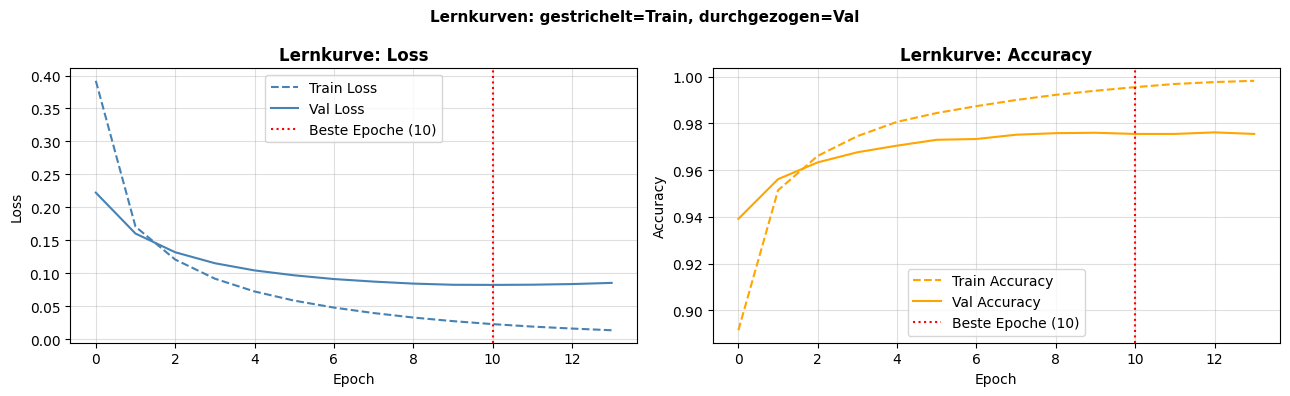

In [10]:
hist_df = pd.DataFrame(history.history)
best_epoch = hist_df['val_loss'].idxmin()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(hist_df['loss'],     color='steelblue', linestyle='--', label='Train Loss')
axes[0].plot(hist_df['val_loss'], color='steelblue', linestyle='-',  label='Val Loss')
axes[0].axvline(x=best_epoch, color='red', linestyle=':', label=f'Beste Epoche ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Lernkurve: Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Accuracy
axes[1].plot(hist_df['accuracy'],     color='orange', linestyle='--', label='Train Accuracy')
axes[1].plot(hist_df['val_accuracy'], color='orange', linestyle='-',  label='Val Accuracy')
axes[1].axvline(x=best_epoch, color='red', linestyle=':', label=f'Beste Epoche ({best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Lernkurve: Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('Lernkurven: gestrichelt=Train, durchgezogen=Val',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


**Mini-Uebung 4:** Interpretieren Sie die Lernkurven.
- Nach wie vielen Epochen hat Early Stopping das Training beendet?
- Gibt es einen sichtbaren Abstand zwischen Train und Val? Was bedeutet das?
- Was waere passiert, wenn wir ohne Early Stopping alle 50 Epochen trainiert haetten?


## 10. Finale Evaluation auf Testdaten

Jetzt erst verwenden wir die Testdaten – einmalig, am Ende.
Das Ergebnis ist die objektive Bewertung des Modells auf voellig
unbekannten Daten.


In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f'Test-Loss:     {test_loss:.4f}')
print(f'Test-Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Val-Accuracy:  {max(history.history["val_accuracy"]):.4f}  (zum Vergleich)')
print()
print(f'Das Modell klassifiziert {test_acc*100:.1f}% der 10.000 Testbilder korrekt.')
print(f'Fehler: {int((1-test_acc)*10000)} von 10.000 Bildern.')


Test-Loss:     0.0730
Test-Accuracy: 0.9794  (97.94%)
Val-Accuracy:  0.9762  (zum Vergleich)

Das Modell klassifiziert 97.9% der 10.000 Testbilder korrekt.
Fehler: 206 von 10.000 Bildern.


## 11. Konfusionsmatrix

Die Konfusionsmatrix zeigt fuer jede Klasse:
- Diagonale: korrekt klassifiziert
- Ausserhalb der Diagonale: Verwechslungen

**Typische MNIST-Verwechslungen:** 3 und 5, 4 und 9, 7 und 1.


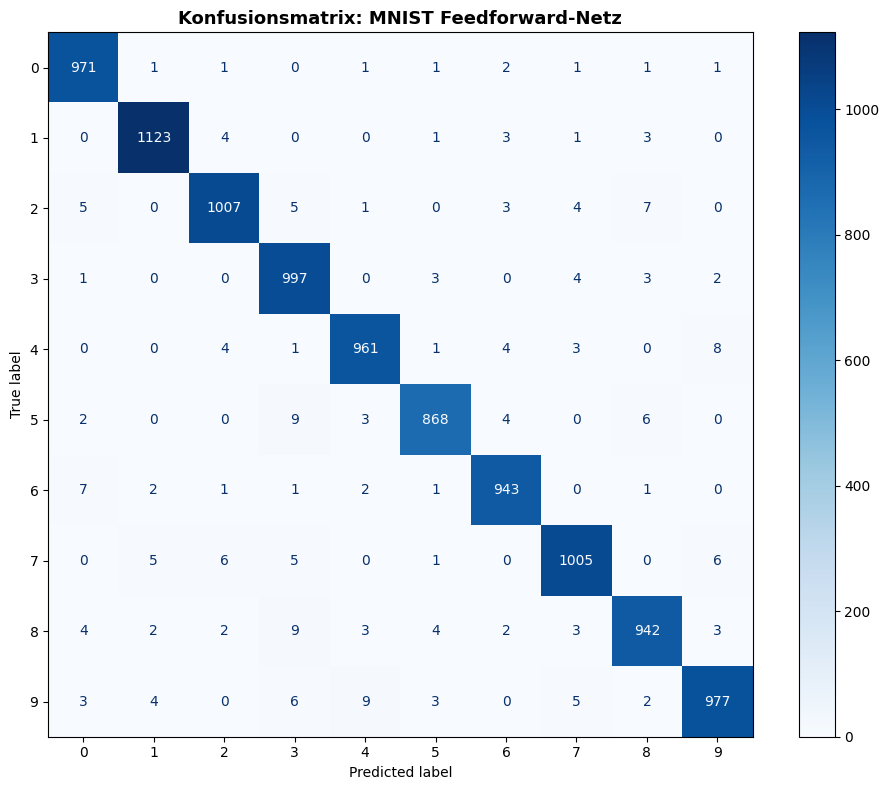

Top-5 Verwechslungspaare (Wahr -> Vorhergesagt | Anzahl):
  8 -> 3 : 9 Mal
  9 -> 4 : 9 Mal
  5 -> 3 : 9 Mal
  4 -> 9 : 8 Mal
  2 -> 8 : 7 Mal


In [12]:
y_pred_prob    = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(
    ax=ax, cmap='Blues', colorbar=True
)
ax.set_title('Konfusionsmatrix: MNIST Feedforward-Netz', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Haeufigste Verwechslungspaare
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
flat_idx = np.argsort(cm_off.ravel())[::-1][:5]
print('Top-5 Verwechslungspaare (Wahr -> Vorhergesagt | Anzahl):')
for idx in flat_idx:
    t, p = idx // 10, idx % 10
    print(f'  {t} -> {p} : {cm_off[t,p]} Mal')


## 12. Fehlklassifikationen visualisieren

Wir schauen uns falsch klassifizierte Bilder an.
Das hilft zu verstehen **warum** das Modell irrt:
- schlechte Handschrift?
- aehnliche Ziffern?
- Sonderfaelle am Rand der Klasse?


Fehlklassifikationen: 206 von 10000 (2.06%)


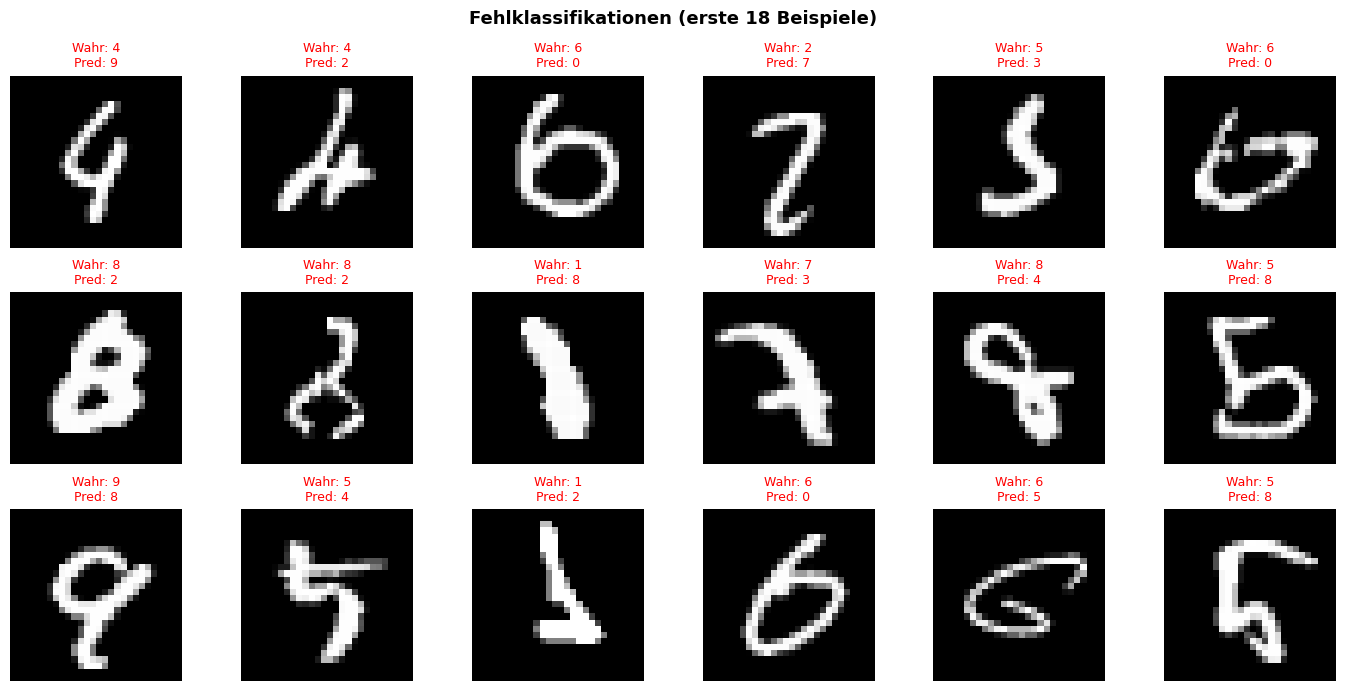

In [13]:
errors = np.where(y_pred_classes != y_test)[0]
print(f'Fehlklassifikationen: {len(errors)} von {len(y_test)} ({len(errors)/len(y_test)*100:.2f}%)')

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
for ax, idx in zip(axes.ravel(), errors[:18]):
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(
        f'Wahr: {y_test[idx]}\nPred: {y_pred_classes[idx]}',
        color='red', fontsize=9
    )
    ax.axis('off')

plt.suptitle('Fehlklassifikationen (erste 18 Beispiele)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Mini-Uebung 5:** Betrachten Sie die falsch klassifizierten Bilder.
- Koennen Sie nachvollziehen, warum das Modell geirrt hat?
- Wuerden Sie als Mensch dieselben Bilder auch falsch klassifizieren?
- Welche Arten von Fehlern wuerden durch ein besseres Modell (CNN) reduziert?


## 13. Fazit

- Ein einfaches Feedforward-Netz erreicht auf MNIST ca. **97-98% Accuracy**.
  Das ist ueberraschend gut fuer einen so einfachen Ansatz.
- Die zentrale Schwaeche: `Flatten()` **zerstoert die raeumliche Struktur**.
  784 Pixel werden als unabhaengige Features behandelt.
  Das Modell hat keine Ahnung, welche Pixel Nachbarn sind.
- **203.530 Parameter** fuer ein relativ simples Problem:
  die vollverbundene Architektur ist ineffizient.
- **Early Stopping** mit `restore_best_weights=True` ist eine einfache
  und effektive Massnahme gegen Overfitting.
- **Ausblick K10_01:** CNNs arbeiten direkt auf dem 2D-Bild,
  erhalten die Nachbarschaft der Pixel und benoetigen dabei
  viel weniger Parameter – bei hoeherer Accuracy.


## 14. Uebungsaufgaben

**Aufgabe 1 – Begriffe erklaeren**
Erklaeren Sie in eigenen Worten:
- Was macht `Flatten()` und warum ist das eine Schwaeche?
- Was bedeutet `patience=3` bei Early Stopping?
- Warum ist `restore_best_weights=True` wichtig?

**Aufgabe 2 – Architektur variieren**
Veraendern Sie das Modell und vergleichen Sie Test-Accuracy und Lernkurven:
- Fuegen Sie einen zweiten Hidden Layer hinzu (z. B. Dense(128))
- Reduzieren Sie auf Dense(64)
- Erhoehen Sie auf Dense(512)

**Aufgabe 3 – Early Stopping analysieren**
- Trainieren Sie dasselbe Modell **ohne** Early Stopping (alle 50 Epochen).
- Vergleichen Sie die Lernkurven mit und ohne Early Stopping.
- Wann beginnt Overfitting sichtbar zu werden?

**Aufgabe 4 – Reflexion**
- Warum verwendet dieses Notebook `sparse_categorical_crossentropy`
  statt `categorical_crossentropy`?
- Warum ist die Normalisierung `/255` besser als `StandardScaler` fuer Bilder?
- Welche Klassen werden am haeufigsten verwechselt und warum?


In [14]:
# Aufgabe 2 - Architektur variieren
# Veraendern Sie die Dense-Layer und beobachten Sie den Effekt.

model_variante = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),   # <- hier variieren
    layers.Dense(128, activation='relu'),   # <- zweiter Layer (neu)
    layers.Dense(10,  activation='softmax')
], name='MNIST_Variante')

model_variante.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_v = model_variante.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )],
    verbose=0
)

_, acc_base = model.evaluate(X_test, y_test, verbose=0)
_, acc_var  = model_variante.evaluate(X_test, y_test, verbose=0)

vergleich = pd.DataFrame({
    'Modell':     ['Basismodell (Dense 256)', 'Variante (Dense 256+128)'],
    'Parameter':  [model.count_params(), model_variante.count_params()],
    'Epochen':    [len(history.history['loss']), len(history_v.history['loss'])],
    'Test-Acc':   [round(acc_base, 4), round(acc_var, 4)]
})
print(vergleich.to_string(index=False))


                  Modell  Parameter  Epochen  Test-Acc
 Basismodell (Dense 256)     203530       14    0.9794
Variante (Dense 256+128)     235146        9    0.9778


---
## 15. Musterloesungen (Dozent)

### Musterloesung Mini-Uebung 1
> Typische Verwechslungspaare: 3 und 5 (aehnliche geschwungene Linien),
> 4 und 9 (aehnliche obere Haelfte), 7 und 1 (schraege vs. senkrechte Linie).
> Gut erkennbar: 0 (geschlossene Form), 1 (einfache senkrechte Linie).
> Schwierig: Alle Ziffern bei sehr krakeliger Handschrift oder
> wenn sie stark von der Norm abweichen.

### Musterloesung Mini-Uebung 2
> Wenn Early Stopping auf Testdaten durchgefuehrt wuerde,
> wuerde das Modell indirekt auf die Testdaten optimiert.
> Das Testergebnis waere dann kein objektives Mass mehr
> fuer die Generalisierung auf neue, unbekannte Daten.
> Die Testdaten muessen voellig unangetastet bleiben.

### Musterloesung Mini-Uebung 3
> Dense(256) mit 784 Eingaben:
> 784 Eingaben x 256 Neuronen = 200.704 Gewichte
> + 256 Bias-Terme (ein Bias pro Neuron) = 200.960 Parameter.
> Flatten() hat keine Parameter: es transformiert nur die Form
> der Daten (28x28 -> 784), berechnet aber nichts Neues.

### Musterloesung Mini-Uebung 4
> Early Stopping stoppt typischerweise nach 10-20 Epochen bei MNIST.
> Train- und Val-Kurven liegen eng beieinander (kein starkes Overfitting).
> Ohne Early Stopping wuerden die Train-Kurven weiter verbessern,
> die Val-Kurven stagnieren oder leicht schlechter werden.
> Das Endmodell waere mit Early Stopping besser.

### Musterloesung Mini-Uebung 5
> Die meisten Fehler sind auch fuer Menschen schwer:
> krakeliges '5' das wie '3' aussieht, schraege '7' die nach '1' aussieht.
> CNNs reduzieren Fehler hauptsaechlich bei Bildern mit leichten
> Verschiebungen oder Rotationen – weil CNNs translationsinvariant sind,
> Feedforward-Netze nicht.

### Musterloesung Aufgabe 1 – Begriffe
> **Flatten():** Wandelt das 28x28-Bild in einen 784-dimensionalen Vektor.
> Schwaeche: Die raeumliche Nachbarschaft der Pixel geht verloren.
> Das Netz weiss nicht mehr, welche Pixel nebeneinander liegen.
>
> **patience=5:** Das Training wird nach 5 aufeinanderfolgenden Epochen
> ohne Verbesserung der Val-Loss beendet.
>
> **restore_best_weights=True:** Nach dem Training werden die Gewichte
> auf die beste beobachtete Epoche zurueckgesetzt – nicht auf die letzte.
> Da spaetere Epochen oft schlechter sind (Overfitting), ist das wichtig.

### Musterloesung Aufgabe 4 – Reflexion
> **sparse vs. categorical CE:**
> `sparse_categorical_crossentropy` akzeptiert Integer-Labels direkt.
> `categorical_crossentropy` benoetigt One-Hot-Encoding.
> Beide sind mathematisch aequivalent; sparse spart Speicher und Code.
>
> **Normalisierung /255 vs. StandardScaler:**
> StandardScaler berechnet pro Pixel einen eigenen Mittelwert (784 Mittelwerte).
> Das loescht globale Helligkeitsinformation und ist unnoetig komplex.
> Pixelwerte haben einen bekannten Bereich [0,255], daher ist
> die einfache Skalierung auf [0,1] Standard fuer Bilddaten.
>
> **Haeufigste Verwechslungen:**
> Typisch: 3 und 5, 4 und 9, 7 und 1.
> Ursache: aehnliche Pixelverteilungen nach dem Flatten-Schritt.
> Ein CNN wuerde lokale Kantenstrukturen erkennen und weniger verwechseln.


In [15]:
# ── Letzte Zelle im Notebook ──
total = time.time() - notebook_start
minuten = int(total // 60)
sekunden = int(total % 60)
print(f"Gesamtlaufzeit: {minuten} min {sekunden} sek")

Gesamtlaufzeit: 1 min 29 sek
